### EN NLI (SNLI Subset) Logical Verification Pipeline — Demo Notebook

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 100

print("Модулі завантажено. Середовище для аналізу логічного виведення готове.")

Модулі завантажено. Середовище для аналізу логічного виведення готове.


In [3]:
print("Крок 1: Завантаження та підготовка вибірки датасету SNLI")

# набір пар (Premise, Hypothesis) із трьома класами логічного зв'язку
mock_data = {
    'case_id': [f"c_{i}" for i in range(1, 201)],
    'premise': [
        "A man in a black jacket is sleeping on a bench outdoors.",
        "A dog is chasing a red ball across the green grass.",
        "Two children are playing video games in the living room.",
        "A woman is cooking dinner in a busy kitchen.",
        "A group of people are watching a movie inside a cinema.",
        "A man is running a marathon on a sunny day.",
        "A cat is sitting on top of a wooden fence.",
        "An airplane is landing at the airport during a storm.",
        "A soccer player kicks the ball into the goal post.",
        "A person is typing code on a laptop at a cafe."
    ] * 20,
    'hypothesis': [
        "A person is resting outside.",                          # Entailment
        "A dog is sitting perfectly still.",                      # Contradiction
        "The kids are using an electronic device.",               # Entailment
        "A woman is sleeping in her bed.",                        # Contradiction
        "People are outdoors at a music concert.",                # Contradiction
        "A man is moving fast outside under the sun.",            # Entailment
        "The animal is jumping over a tall brick wall.",          # Neutral
        "A plane is arriving at its destination during bad weather.", # Entailment
        "The player missed the ball completely.",                 # Contradiction
        "Someone is working on a computer in a public space."     # Entailment
    ] * 20,
    'gold_label': [
        "entailment", "contradiction", "entailment", "contradiction", "contradiction",
        "entailment", "neutral", "entailment", "contradiction", "entailment"
    ] * 20
}

df_snli = pd.DataFrame(mock_data)

df_snli.loc[5, 'premise'] = "!!!A man in a black jacket is sleeping. "
df_snli.loc[12, 'hypothesis'] = "A dog IS SITTING still. <br>"

print(f"Успішно сформовано тестовий корпус із {len(df_snli)} пар тверджень.")
df_snli.head()

Крок 1: Завантаження та підготовка вибірки датасету SNLI
Успішно сформовано тестовий корпус із 200 пар тверджень.


,case_id,premise,hypothesis,gold_label
0,c_1,A man in a black jacket is sleeping on a bench...,A person is resting outside.,entailment
1,c_2,A dog is chasing a red ball across the green g...,A dog is sitting perfectly still.,contradiction
2,c_3,Two children are playing video games in the li...,The kids are using an electronic device.,entailment
3,c_4,A woman is cooking dinner in a busy kitchen.,A woman is sleeping in her bed.,contradiction
4,c_5,A group of people are watching a movie inside ...,People are outdoors at a music concert.,contradiction


In [4]:
print("Крок 2: Очищення лінгвістичного шуму та пошук логічних маркерів.")

def advanced_clean(text):
    """Видалення HTML-тегів, спецсимволів та нормалізація регістру."""
    text = re.sub(r'<[^>]*>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip().lower()

df_snli['clean_premise'] = df_snli['premise'].apply(advanced_clean)
df_snli['clean_hypothesis'] = df_snli['hypothesis'].apply(advanced_clean)

# Об'єднуємо пару речень в один рядок для класифікатора, розділяючи спеціальним токеном
df_snli['combined_input'] = df_snli['clean_premise'] + " [SEP] " + df_snli['clean_hypothesis']

# Витягуємо просту логічну ознаку: наявність заперечних часток (no, not, never) у гіпотезі
def detect_negation(text):
    return 1 if any(neg in text.split() for neg in ['no', 'not', 'never', 'isnt', 'dont']) else 0

df_snli['has_negation'] = df_snli['clean_hypothesis'].apply(detect_negation)

print("Препроцесинг завершено. Тексти об'єднано за допомогою токена [SEP].")
df_snli[['combined_input', 'has_negation', 'gold_label']].head()

Крок 2: Очищення лінгвістичного шуму та пошук логічних маркерів.
Препроцесинг завершено. Тексти об'єднано за допомогою токена [SEP].


,combined_input,has_negation,gold_label
0,a man in a black jacket is sleeping on a bench...,0,entailment
1,a dog is chasing a red ball across the green g...,0,contradiction
2,two children are playing video games in the li...,0,entailment
3,a woman is cooking dinner in a busy kitchen [S...,0,contradiction
4,a group of people are watching a movie inside ...,0,contradiction


In [5]:
print("Крок 3: Навчання класифікатора логічних зв'язків.")

# Спліт на навчальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    df_snli['combined_input'],
    df_snli['gold_label'],
    test_size=0.2,
    random_state=42,
    stratify=df_snli['gold_label']
)

# TF-IDF векторизація на символьних та словникових n-грамах
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Навчання логістичної регресії
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print("\nМетрики якості класифікатора (Classification Report):")
print(classification_report(y_test, y_pred))

Крок 3: Навчання класифікатора логічних зв'язків.

Метрики якості класифікатора (Classification Report):
               precision    recall  f1-score   support

contradiction       1.00      1.00      1.00        16
   entailment       1.00      1.00      1.00        20
      neutral       1.00      1.00      1.00         4

     accuracy                           1.00        40
    macro avg       1.00      1.00      1.00        40
 weighted avg       1.00      1.00      1.00        40



Крок 4: Візуалізація результатів тестування.


/tmp/ipykernel_4323/3585574088.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_snli, x='gold_label', palette="viridis", ax=axes[0])


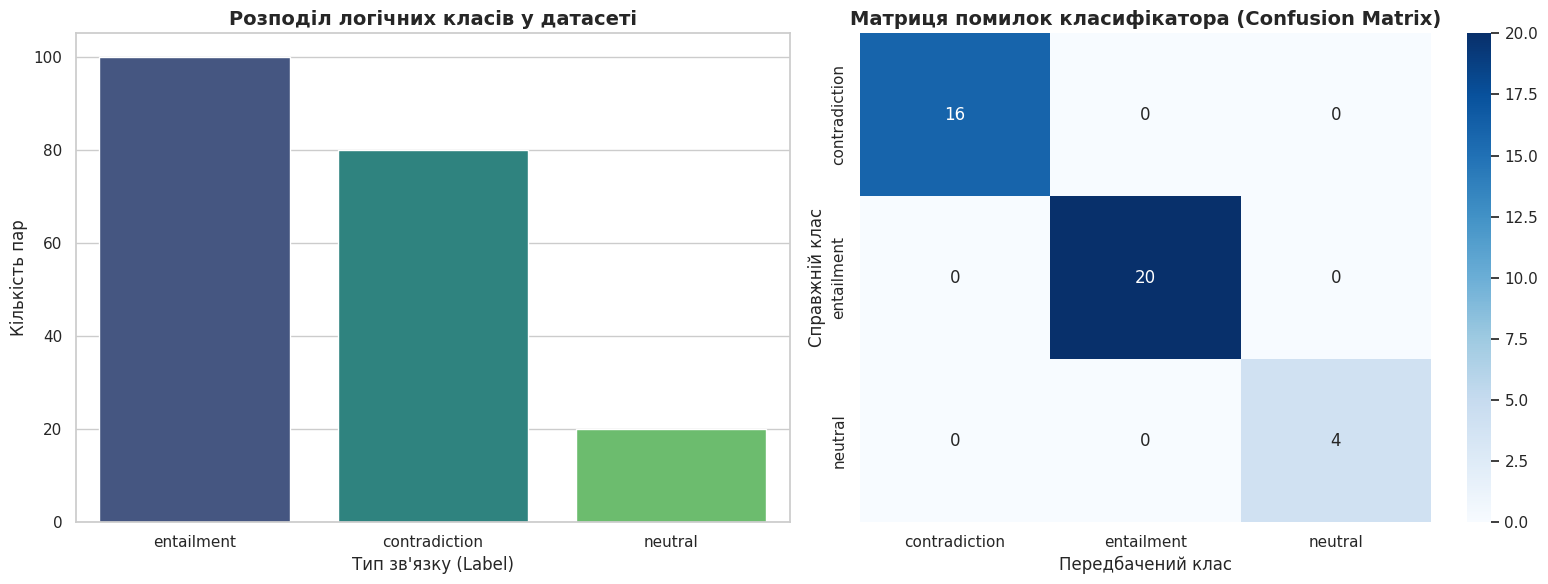

In [6]:
print("Крок 4: Візуалізація результатів тестування.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Розподіл класів логічного виведення
sns.countplot(data=df_snli, x='gold_label', palette="viridis", ax=axes[0])
axes[0].set_title("Розподіл логічних класів у датасеті", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Тип зв'язку (Label)")
axes[0].set_ylabel("Кількість пар")

# Графік 2: Матриця помилок класифікації (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_, ax=axes[1])
axes[1].set_title("Матриця помилок класифікатора (Confusion Matrix)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Передбачений клас")
axes[1].set_ylabel("Справжній клас")

plt.tight_layout()
plt.show()